# Heart Disease Prediction using Machine Learning

## Atigala AVDSK (IT22589972)

### Task:
- Data Loading & Preprocessing
- Random Forest Model Implementation
- Model Evaluation

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [1169]:
# Load dataset
df = pd.read_csv("../data/heart.csv")

# Display first 5 rows to understand data structure
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [1170]:
# Convert categorical variables into numeric format
# This is required for machine learning models
df = pd.get_dummies(df, drop_first=True)

In [1171]:
# Split dataset into features (X) and target variable (y)

# X = input features (all columns except target)
# y = output label (HeartDisease)

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [1172]:
# Split data into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [1173]:
# Create Random Forest model
# n_estimators = number of decision trees

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
)

# Train the model using training data
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [1174]:
# Make predictions on test data
y_pred_rf = rf_model.predict(X_test)

In [1175]:
# Evaluate model accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("===== Random Forest Results =====")
print("Accuracy:", rf_accuracy)

===== Random Forest Results =====
Accuracy: 0.8804347826086957


In [1176]:
# Confusion Matrix
# Shows correct and incorrect predictions

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[66 11]
 [11 96]]


In [1177]:
# Classification Report
# Includes precision, recall, f1-score

print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



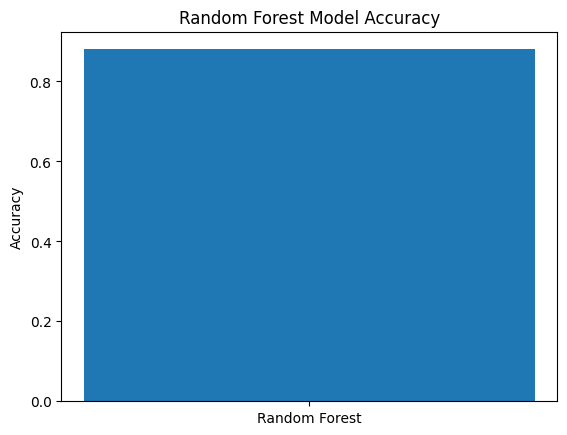

In [1178]:
# Visualize model accuracy

plt.bar(["Random Forest"], [rf_accuracy])
plt.title("Random Forest Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

In [1179]:
import json

results = {"Random Forest": rf_accuracy}

with open("../comparison/random_forest.json", "w") as f:
    json.dump(results, f)